In [3]:
from google.colab import files
uploaded = files.upload()

Saving European_Bank - European_Bank.csv to European_Bank - European_Bank (1).csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [6]:
df = pd.read_csv("European_Bank - European_Bank (1).csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
df = df.drop(['CustomerId','Surname'], axis=1)

In [8]:
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

In [9]:
df['AgeGroup'] = pd.cut(df['Age'],
                       bins=[18,30,45,60,100],
                       labels=['<30','30-45','46-60','60+'])

In [10]:
df['CreditGroup'] = pd.cut(df['CreditScore'],
                          bins=[300,580,700,900],
                          labels=['Low','Medium','High'])

In [11]:
df['TenureGroup'] = pd.cut(df['Tenure'],
                          bins=[0,3,7,10],
                          labels=['New','Mid','Loyal'])

In [12]:
df['BalanceGroup'] = pd.cut(df['Balance'],
                           bins=[-1,0,100000,250000],
                           labels=['Zero','Low','High'])

In [13]:
churn_rate = df['Exited'].mean()
print("Overall Churn Rate:", churn_rate)

Overall Churn Rate: 0.2037


In [14]:
df.groupby('AgeGroup')['Exited'].mean()

/tmp/ipykernel_13422/2100907710.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')['Exited'].mean()


,Exited
AgeGroup,
<30,0.075026
30-45,0.157406
46-60,0.511233
60+,0.247845


In [15]:
df.groupby('Gender')['Exited'].mean()

,Exited
Gender,
0,0.250715
1,0.164559


In [16]:
df.groupby(['Geography_Germany','Geography_Spain'])['Exited'].mean()

Geography_Germany  Geography_Spain
False              False              0.161548
                   True               0.166734
True               False              0.324432
Name: Exited, dtype: float64

/tmp/ipykernel_13422/2636834587.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')['Exited'].mean().plot(kind='bar')


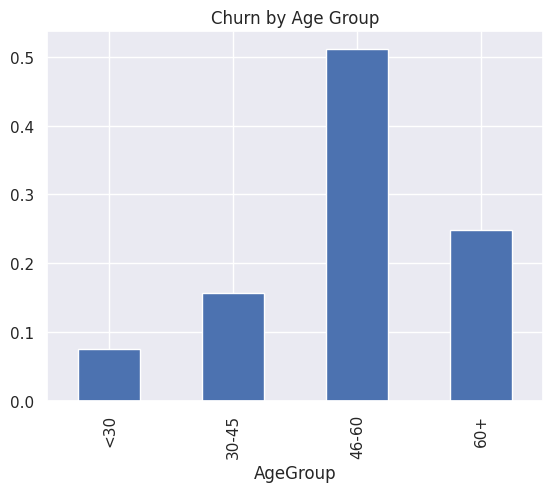

In [17]:
df.groupby('AgeGroup')['Exited'].mean().plot(kind='bar')
plt.title("Churn by Age Group")
plt.show()

/tmp/ipykernel_13422/3237922545.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('BalanceGroup')['Exited'].mean().plot(kind='bar')


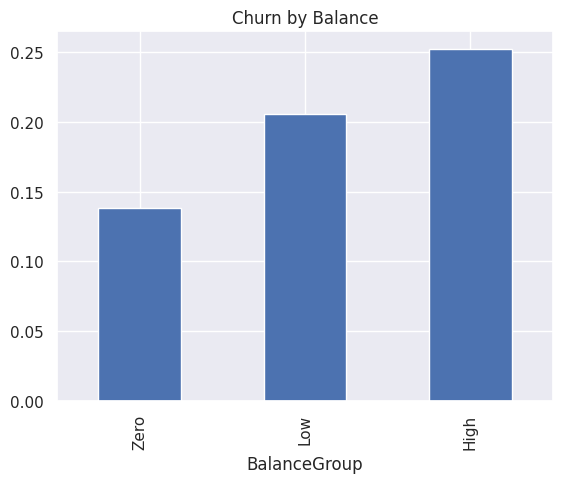

In [18]:
df.groupby('BalanceGroup')['Exited'].mean().plot(kind='bar')
plt.title("Churn by Balance")
plt.show()

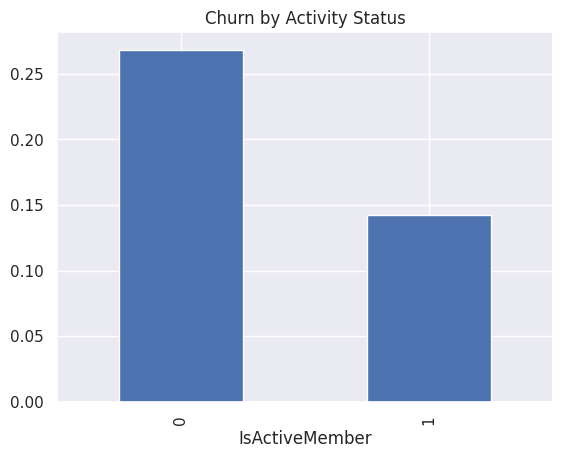

In [19]:
df.groupby('IsActiveMember')['Exited'].mean().plot(kind='bar')
plt.title("Churn by Activity Status")
plt.show()

In [20]:
high_value = df[df['Balance'] > 100000]

print("High Value Churn Rate:", high_value['Exited'].mean())

High Value Churn Rate: 0.25234423838299647


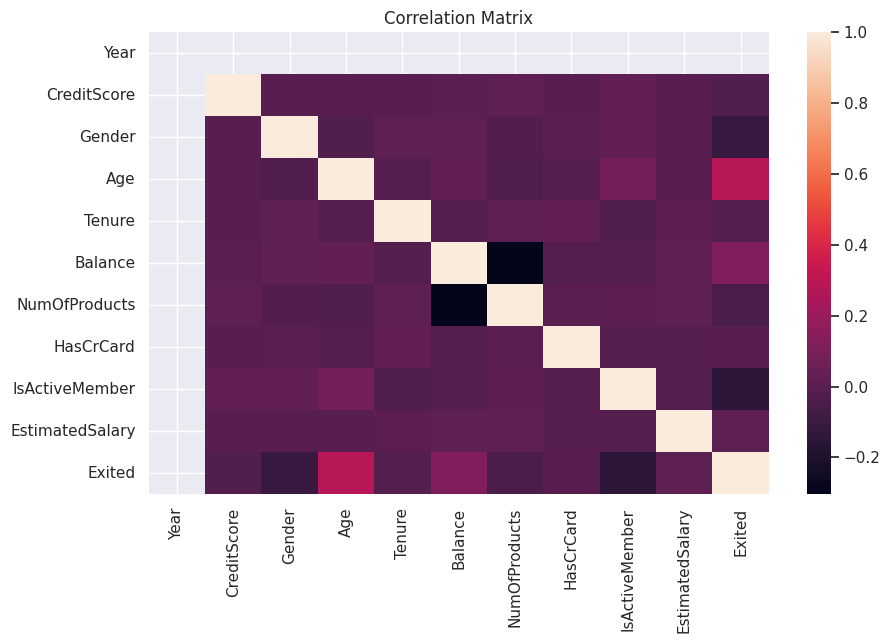

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=False)
plt.title("Correlation Matrix")
plt.show()

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df.drop('Exited', axis=1)
y = df['Exited']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.8335


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
df.to_csv("processed_data.csv", index=False)

In [26]:
files.download("processed_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>